In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(ggplotify))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

donors <- c('C29', 'C37', 'C38', 'C39')
donor_order <- donors
donor_hexes <- c('#2851B0', '#C445B8', '#70373D', '#CFCF42')

tmp_order <- c('Start', 'Sendai', 'Delayed', 'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#9C4F43', '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')

pmds_order <- c('PMDs', 'Non-PMDs')
pmd_hexes <- c('#BD2608', '#6FA2E3')

all_order <- c('Start', 'Sendai', 'Skin', 'Inflamed', 'Delayed',
               'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
all_hexes <- c('#C4B921', '#707332', '#3CADBA', '#83E880', '#9C4F43',
                 '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')
names(all_hexes) <- all_order
names(donor_hexes) <- donors

base_theme <- theme(
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### A: PMD Jaccard index between donors

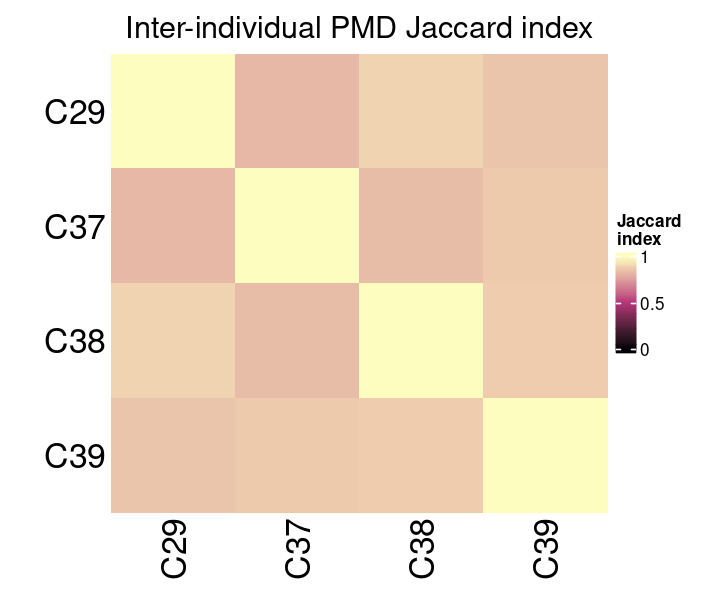

In [ ]:
jaccard_path = paste0(projdir, '/csv/figure2/pmds_jaccard_df.csv')
jaccard = as.data.frame(fread(jaccard_path, sep='\t')[,2:5])
rownames(jaccard) <- donor_order

col_fun <- colorRamp2(c(0, 0.5, 1), viridis::magma(3))

w = 6
h = 5
options(repr.plot.width=w, repr.plot.height=h)

igvf_heatmap <- Heatmap(jaccard,
                        name='Jaccard\nindex',
                    row_names_side = "left",
                    column_names_side = "bottom",
                    col = col_fun,
                    column_title = 'Inter-individual PMD Jaccard index',
                    column_title_side = "top",
                    row_title = '',
                    show_heatmap_legend = TRUE,
                    show_column_names=TRUE,
                    show_row_names=TRUE,
                    row_title_gp = gpar(fontsize = 24),
                    column_title_gp = gpar(fontsize = 18),
                    column_names_rot = 90,
                    heatmap_width = unit(12, "cm"),
                    heatmap_height = unit(12, "cm"),
                    row_names_gp = gpar(fontsize = 20),
                    column_names_gp = gpar(fontsize = 20),
                    cluster_rows = FALSE,
                    cluster_columns = FALSE)
igvf_heatmap

### B: PMD metagene, replicate snmCT-seq

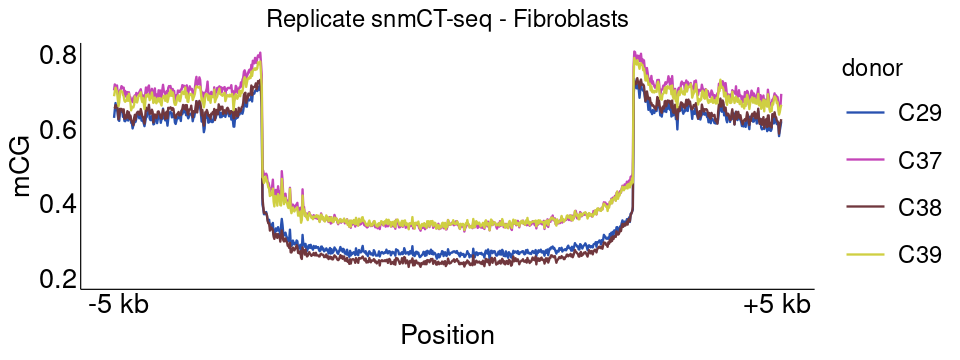

In [ ]:
wagner_flank_path = paste0(projdir, '/csv/figure2/wagner_pmds_flank_metagene.csv')
wagner_flank = read.csv(wagner_flank_path, sep='\t')

slack = 6
tmp_breaks <- c(min(wagner_flank$tmp) + slack, max(wagner_flank$tmp) - slack)
wagner_hexes <- c("#41ab5d", "#3182bd", "#6a51a3")

rep_flank_path = paste0(projdir, '/csv/figure3/50_line_pmds_flank_metagene.csv')
rep_flank = read.csv(rep_flank_path, sep='\t')
mask <- rep_flank$time == 'D0'
rep_flank <- rep_flank[mask,]
rep_flank$sample <- gsub('D0', '', rep_flank$sample)

w = 8
h = 3
options(repr.plot.width=w, repr.plot.height=h)

ggplot(rep_flank, aes(x = tmp, y = X0, color = donor, group = sample)) +
  geom_line(size = 0.5) +
  labs(x = "Position", y = "mCG", title='Replicate snmCT-seq - Fibroblasts') +
 coord_cartesian(ylim = c(0.2, 0.8)) +
    scale_x_continuous(breaks = tmp_breaks, labels = c("-5 kb", "+5 kb")) +
  theme_bw() +
   theme(axis.text.x = element_text(size=16, color='black'),
        axis.text.y = element_text(size=16,angle=0, color='black'),
        axis.title.x = element_text(size=16),
        axis.title.y = element_text(size=16),
        axis.ticks.x = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.x = element_line(size=0.25),
      axis.line.y = element_line(size=0.25),
         panel.border = element_blank(),
         panel.grid = element_blank(),
         panel.background = element_blank(),
         plot.background  = element_blank(),

         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 14),
         legend.title = element_text(size=14),
        plot.title = element_text(size = 14, hjust = 0.5)) +
        scale_color_manual(values = donor_hexes) +
          guides(color = guide_legend(override.aes = list(size = 5)),
            shape = guide_legend(title = ''))

### C: PMD metagene, independent snmCT-seq

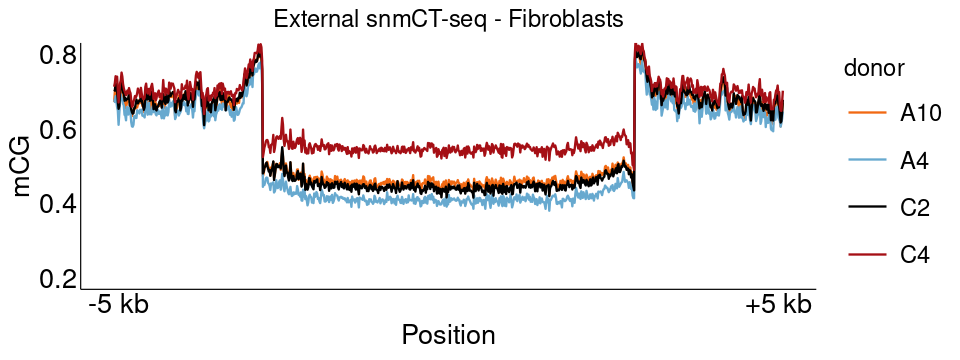

In [ ]:
pilot_flank_path = paste0(projdir, '/csv/figure2/pilot_pmds_flank_metagene.csv')
pilot_flank = read.csv(pilot_flank_path, sep='\t')

slack = 6
tmp_breaks <- c(min(wagner_flank$tmp) + slack, max(wagner_flank$tmp) - slack)
pilot_hexes <- c("#f16913", "#67a9cf", "#000000", "#a50f15")

w = 8
h = 3
options(repr.plot.width=w, repr.plot.height=h)

ggplot(pilot_flank, aes(x = tmp, y = X0, color = donor, group = sample)) +
  geom_line(size = 0.5) +
  labs(x = "Position", y = "mCG", title='External snmCT-seq - Fibroblasts') +
 coord_cartesian(ylim = c(0.2, 0.8)) +
    scale_x_continuous(breaks = tmp_breaks, labels = c("-5 kb", "+5 kb")) +
  theme_bw() +
   theme(axis.text.x = element_text(size=16, color='black'),
        axis.text.y = element_text(size=16,angle=0, color='black'),
        axis.title.x = element_text(size=16),
        axis.title.y = element_text(size=16),
        axis.ticks.x = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.x = element_line(size=0.25),
      axis.line.y = element_line(size=0.25),
         panel.border = element_blank(),
         panel.grid = element_blank(),
         panel.background = element_blank(),
         plot.background  = element_blank(),

         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 14),
         legend.title = element_text(size=14),
        plot.title = element_text(size = 14, hjust = 0.5)) +
        scale_color_manual(values = pilot_hexes) +
          guides(color = guide_legend(override.aes = list(size = 5)),
            shape = guide_legend(title = ''))

### D: PMD metagene, bulk fibroblast WGBS

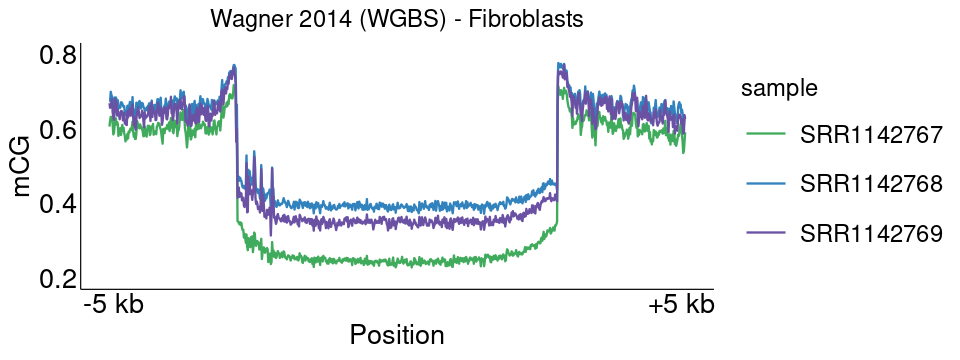

In [ ]:
w = 8
h = 3
options(repr.plot.width=w, repr.plot.height=h)

ggplot(wagner_flank, aes(x = tmp, y = X0, color = sample, group = sample)) +
  geom_line(size = 0.5) +
labs(x = "Position", y = "mCG", title='Wagner 2014 (WGBS) - Fibroblasts') +
 coord_cartesian(ylim = c(0.2, 0.8)) +
    scale_x_continuous(breaks = tmp_breaks, labels = c("-5 kb", "+5 kb")) +
  theme_bw() +
   theme(axis.text.x = element_text(size=16, color='black'),
        axis.text.y = element_text(size=16,angle=0, color='black'),
        axis.title.x = element_text(size=16),
        axis.title.y = element_text(size=16),
        axis.ticks.x = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.x = element_line(size=0.25),
      axis.line.y = element_line(size=0.25),
         panel.border = element_blank(),
         panel.grid = element_blank(),
         panel.background = element_blank(),
         plot.background  = element_blank(),
         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 14),
         legend.title = element_text(size=14),
        plot.title = element_text(size = 14, hjust = 0.5)) +
        scale_color_manual(values = wagner_hexes) +
          guides(color = guide_legend(override.aes = list(size = 10)),
            shape = guide_legend(title = ''))

### E: PMD genomic coverage

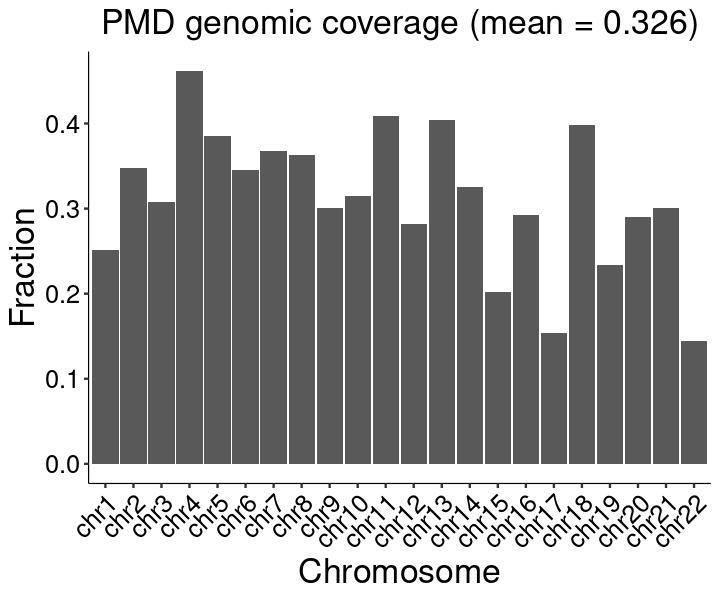

In [ ]:
gcov_path = paste0(projdir, '/csv/figure2/pmd_union.cov.csv')
gcov = as.data.frame(fread(gcov_path, sep='\t'))

mask <- gcov$start == 1
tmp_gcov <- gcov[mask,]
tmp_gcov <- tmp_gcov[1:22,]

auto <- paste0('chr', 1:22)
tmp_gcov$chrom <- factor(tmp_gcov$chrom, levels=auto)

w = 6
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(tmp_gcov, aes(x = chrom, y = score, )) +
  geom_bar(stat='identity') +
labs(x = "Chromosome", y = "Fraction",
         title = 'PMD genomic coverage (mean = 0.326)') +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 15, color='black'),
    axis.text.y = element_text(size = 15, color='black'),
    axis.title.x = element_text(size = 20, color='black'),
    axis.title.y = element_text(size = 20, color='black'),
    plot.title = element_text(size=20, hjust=0.5),
    strip.text = element_text(size = 14),
      axis.line.x = element_line(size=0.25),
      axis.line.y = element_line(size=0.25),
     panel.border = element_blank(),
     panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
  ) +
  scale_fill_manual('blue')

### F: PMD size distribution

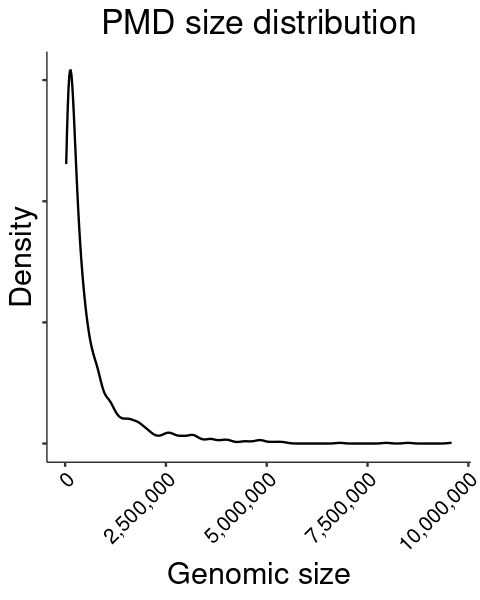

In [ ]:
indir = '/u/project/cluo/terencew/igvf/2023_YR2/snmCT/pseudobulk_allc/pmds/dnmtools/rna_cluster_donor'
pmds_path = paste0(indir, '/merged/start_merged.filt_mcg.sorted.bed.gz')
pmds = as.data.frame(fread(pmds_path, sep='\t'))
pmds$size <- pmds$V3 - pmds$V2

w = 4
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(pmds, aes(x = size)) +
  geom_density(position = "stack", alpha = 0.9) +
labs(x = "Genomic size", y = "Density",
         title = 'PMD size distribution') +
  scale_x_continuous(labels = comma) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size = 12, angle = 45, hjust = 1, color='black'),
    axis.text.y = element_blank(),
    axis.title.x = element_text(size = 18),
    axis.title.y = element_text(size = 18),
    plot.title = element_text(size=20, hjust=0.5),
      axis.line.x = element_line(size=0.25),
      axis.line.y = element_line(size=0.25),
     panel.border = element_blank(),
     panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
  )

### G: observed vs. expected gene overlap

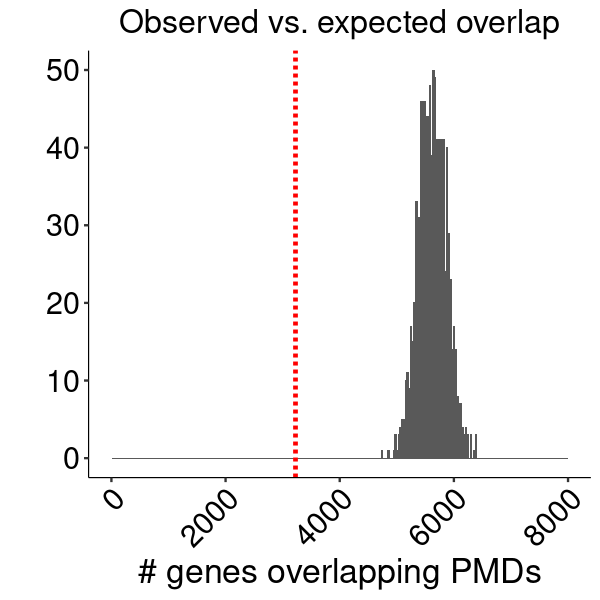

In [ ]:
pmds_genes_path = paste0(projdir, '/csv/figure2/pmds_genes_exp_overlap.csv')
pmds_genes = as.data.frame(fread(pmds_genes_path, sep='\t'))

obs <- pmds_genes[pmds_genes$type == 'observed',]$num
exp <- pmds_genes[pmds_genes$type != 'observed',]

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(exp, aes(x = num)) +
  geom_histogram(binwidth = 30) +
  geom_vline(xintercept = obs, color = "red", linetype = "dashed", size = 1) +
  labs(x = "# genes overlapping PMDs", y = "",
         title = 'Observed vs. expected overlap') +
  scale_x_continuous(limits=c(0, 8000)) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 18, color='black'),
    axis.text.y = element_text(size = 18, color='black'),
    axis.title = element_text(size = 20),
    plot.title = element_text(size=19, hjust=0.5),
      axis.line.x = element_line(size=0.25),
      axis.line.y = element_line(size=0.25),
     panel.border = element_blank(),
     panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank()
  )

### H: Repli-seq signal in PMDs

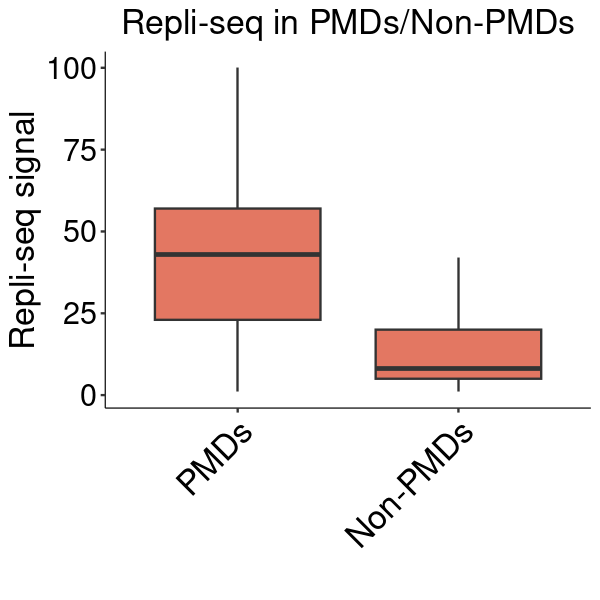

In [ ]:
repli_path = paste0(projdir, '/csv/figure2/pmds_repli_seq.csv')
repli = fread(repli_path, sep='\t')
repli$type <- factor(repli$type, levels=pmds_order)

hex = c('#E37762')

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(repli, aes(x = type, y = name)) +
  geom_boxplot(fill=hex, outlier.shape=NA) +
labs(x = "", y = "Repli-seq signal", title = 'Repli-seq in PMDs/Non-PMDs') +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 20, color='black'),
    axis.text.y = element_text(size = 18, color='black'),
    axis.title = element_text(size = 20),
    plot.title = element_text(size=20, hjust=0.5),
        axis.line.x = element_line(size=0.25),
      axis.line.y = element_line(size=0.25),
     panel.border = element_blank(),
     panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
  )

### I: RNA inside/outside PMDs, all genes

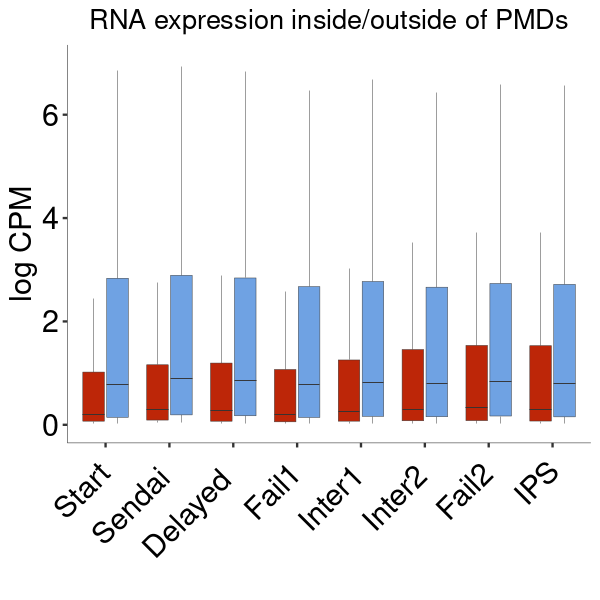

In [ ]:
pmds_expr_path = paste0(projdir, '/csv/figure2/rna_expr_in_pmds.csv')
pmds_expr = as.data.frame(fread(pmds_expr_path, sep='\t'))
pmds_expr$cluster <- factor(pmds_expr$cluster, levels=tmp_order)
pmds_expr$type <- gsub("non-pmds", "Non-PMDs", pmds_expr$type)
pmds_expr$type <- gsub("pmds", "PMDs", pmds_expr$type)
pmds_expr$type <- factor(pmds_expr$type, levels=pmds_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(pmds_expr, aes(x = cluster, y = expr, fill = type)) +
  geom_boxplot(outlier.shape = NA, linewidth=0.1) +
  labs(x = "",y = "log CPM",
       title = "RNA expression inside/outside of PMDs",
        fill = "Type"
  ) +
  ylim(0, 7) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size = 18, angle = 45, hjust = 1.2, color='black'),
    axis.text.y = element_text(size = 18, color='black'),
    axis.title = element_text(size = 18),
    plot.title = element_text(size = 16, hjust = 0.5),
      axis.line.x = element_line(linewidth=0.1),
      axis.line.y = element_line(linewidth=0.1),
     panel.border = element_blank(),
     panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
    legend.position = "none"
  ) +
  scale_fill_manual(values=pmd_hexes)

### J: RNA inside/outside PMDs, DEGs

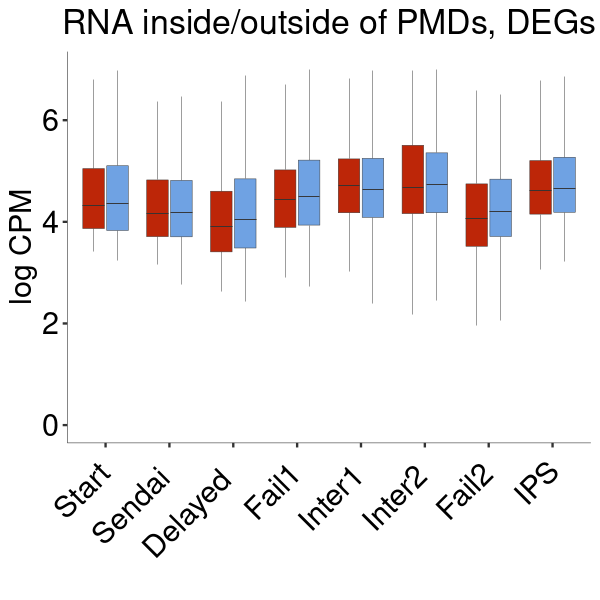

In [ ]:
pmds_degs_path = paste0(projdir, '/csv/figure2/rna_expr_degs_in_pmds.csv')
pmds_degs = read.csv(pmds_degs_path, sep='\t')
pmds_degs$cluster <- factor(pmds_degs$cluster, levels=tmp_order)
pmds_degs$type <- gsub("non-pmds", "Non-PMDs", pmds_degs$type)
pmds_degs$type <- gsub("pmds", "PMDs", pmds_degs$type)
pmds_degs$type <- factor(pmds_degs$type, levels=pmds_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(pmds_degs, aes(x = cluster, y = expr, fill = type)) +
  geom_boxplot(outlier.shape = NA, linewidth=0.1) +
  labs(x = "",y = "log CPM",
       title = "RNA inside/outside of PMDs, DEGs",
        fill = "Type"
  ) +
  ylim(0, 7) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size = 18, angle = 45, hjust = 1.2, color='black'),
    axis.text.y = element_text(size = 18, color='black'),
    axis.title = element_text(size = 18),
    plot.title = element_text(size = 20, hjust = 0.5),
      axis.line.x = element_line(linewidth=0.1),
      axis.line.y = element_line(linewidth=0.1),
     panel.border = element_blank(),
     panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
    legend.position = "none"
  ) +
  scale_fill_manual(values=pmd_hexes)

### K: DEG expression vs. distance to PMD

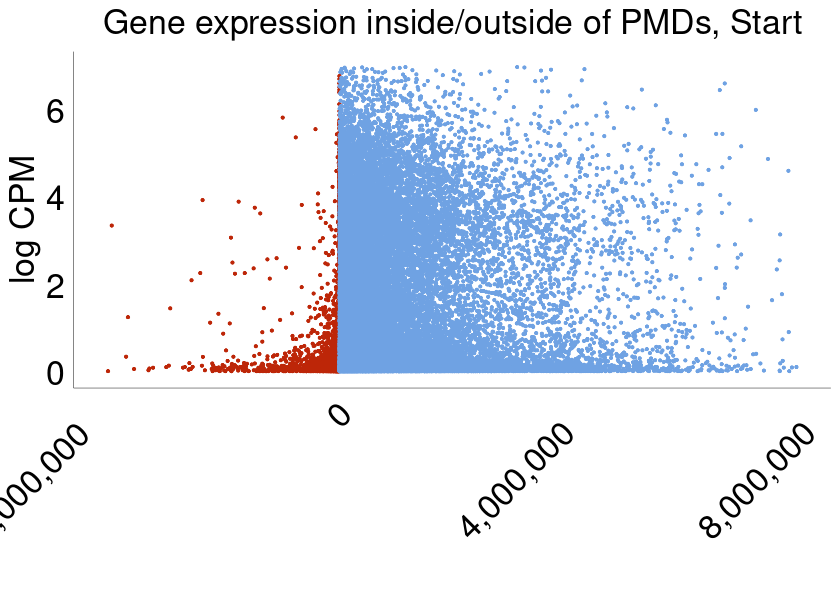

In [ ]:
pmds_genes_dist_path = paste0(projdir, '/csv/figure2/rna_expr_genes_dist_start.csv')
pmds_genes_dist = read.csv(pmds_genes_dist_path, sep='\t')
pmds_genes_dist$type <- gsub("non-pmds", "Non-PMDs", pmds_genes_dist$type)
pmds_genes_dist$type <- gsub("pmds", "PMDs", pmds_genes_dist$type)
pmds_genes_dist$type <- factor(pmds_genes_dist$type, levels=pmds_order)

w = 7
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(pmds_genes_dist, aes(x = dist, y = expr, color = type)) +
  geom_point_rast(size=0.3) +
  labs(x = "",y = "log CPM", title = "Gene expression inside/outside of PMDs, Start") +
  ylim(0, 7) +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 20, angle = 45, hjust = 1.2, color='black'),
    axis.text.y = element_text(size = 20, color='black'),
    axis.title = element_text(size = 20),
    plot.title = element_text(size = 20, hjust = 0.5),
      axis.line.x = element_line(linewidth=0.1),
      axis.line.y = element_line(linewidth=0.1),
    legend.position = "none"
  ) +
  scale_color_manual(values=pmd_hexes) +
    scale_x_continuous(labels = scales::comma)

### L: ATAC inside/outside PMDs, all peaks

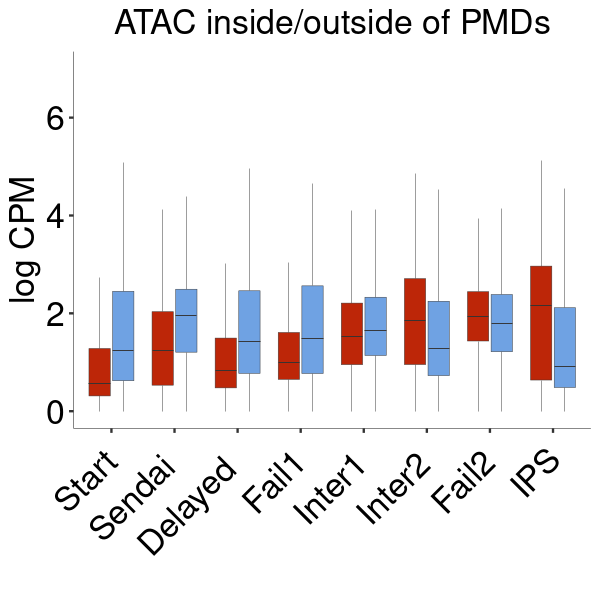

In [ ]:
pmds_atac_path = paste0(projdir, '/csv/figure2/atac_expr_in_pmds.csv')
pmds_atac = read.csv(pmds_atac_path, sep='\t')
pmds_atac$cluster <- factor(pmds_atac$cluster, levels=tmp_order)
pmds_atac$type <- gsub("non-pmds", "Non-PMDs", pmds_atac$type)
pmds_atac$type <- gsub("pmds", "PMDs", pmds_atac$type)
pmds_atac$type <- factor(pmds_atac$type, levels=pmds_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(pmds_atac, aes(x = cluster, y = expr, fill = type)) +
  geom_boxplot(outlier.shape = NA, linewidth=0.1) +
  labs(x = "",y = "log CPM",
       title = "ATAC inside/outside of PMDs",
        fill = "Type"
  ) +
  ylim(0, 7) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size = 20, angle = 45, hjust = 1.2, color='black'),
    axis.text.y = element_text(size = 20, color='black'),
    axis.title = element_text(size = 20),
    plot.title = element_text(size = 20, hjust = 0.5),
      axis.line.x = element_line(linewidth=0.1),
      axis.line.y = element_line(linewidth=0.1),
     panel.border = element_blank(),
     panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
    legend.position = "none"
  ) +
  scale_fill_manual(values=pmd_hexes)

### M: ATAC inside/outside PMDs, differential peaks

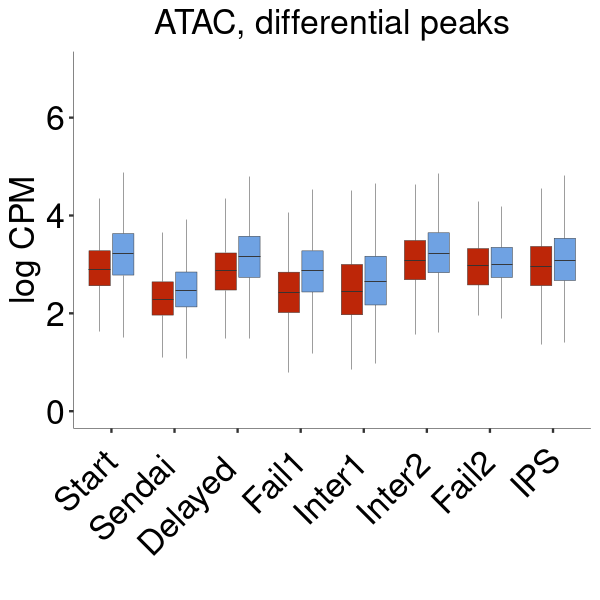

In [ ]:
pmds_atac_path = paste0(projdir, '/csv/figure2/atac_diff_expr_in_pmds.csv')
pmds_atac = read.csv(pmds_atac_path, sep='\t')
pmds_atac$cluster <- factor(pmds_atac$cluster, levels=tmp_order)
pmds_atac$type <- gsub("non-pmds", "Non-PMDs", pmds_atac$type)
pmds_atac$type <- gsub("pmds", "PMDs", pmds_atac$type)
pmds_atac$type <- factor(pmds_atac$type, levels=pmds_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(pmds_atac, aes(x = cluster, y = expr, fill = type)) +
  geom_boxplot(outlier.shape = NA, linewidth=0.1) +
  labs(x = "",y = "log CPM",
       title = "ATAC, differential peaks",
        fill = "Type"
  ) +
  ylim(0, 7) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size = 20, angle = 45, hjust = 1.2, color='black'),
    axis.text.y = element_text(size = 20, color='black'),
    axis.title = element_text(size = 20),
    plot.title = element_text(size = 20, hjust = 0.5),
      axis.line.x = element_line(linewidth=0.1),
      axis.line.y = element_line(linewidth=0.1),
     panel.border = element_blank(),
     panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
    legend.position = "none"
  ) +
  scale_fill_manual(values=pmd_hexes)

### N: peak accessibility vs. distance to PMD

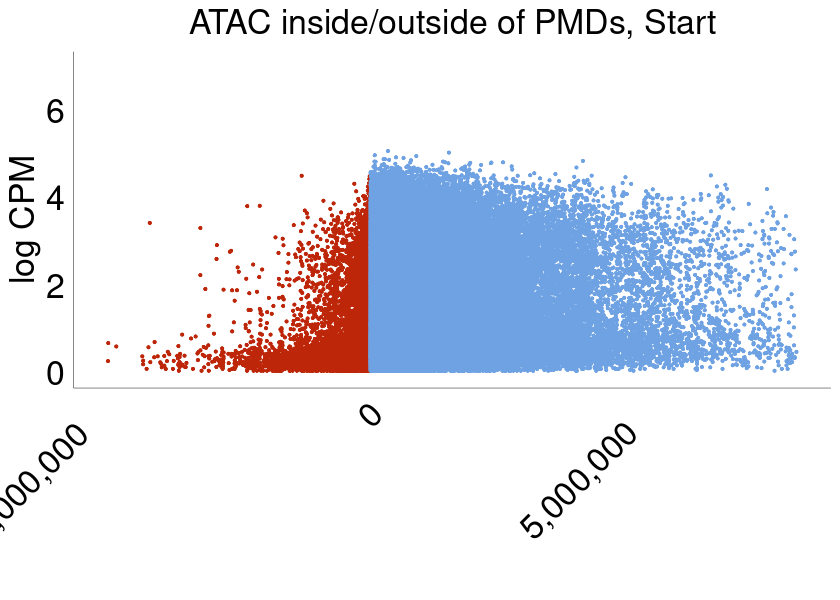

In [ ]:
pmds_peaks_dist_path = paste0(projdir, '/csv/figure2/atac_peaks_dist_start.csv')
pmds_peaks_dist = read.csv(pmds_peaks_dist_path, sep='\t')
pmds_peaks_dist$type <- gsub("non-pmds", "Non-PMDs", pmds_peaks_dist$type)
pmds_peaks_dist$type <- gsub("pmds", "PMDs", pmds_peaks_dist$type)
pmds_peaks_dist$type <- factor(pmds_peaks_dist$type, levels=pmds_order)

w = 7
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(pmds_peaks_dist, aes(x = dist, y = expr, color = type)) +
  geom_point_rast(size=0.3) +
  labs(x = "",y = "log CPM", title = "ATAC inside/outside of PMDs, Start") +
  ylim(0, 7) +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 20, angle = 45, hjust = 1.2, color='black'),
    axis.text.y = element_text(size = 20, color='black'),
    axis.title = element_text(size = 20),
    plot.title = element_text(size = 20, hjust = 0.5),
      axis.line.x = element_line(linewidth=0.1),
      axis.line.y = element_line(linewidth=0.1),
    legend.position = "none"
  ) +
  scale_color_manual(values=pmd_hexes) +
    scale_x_continuous(labels = scales::comma)

### O: PMD mCG correlation between cluster/donor

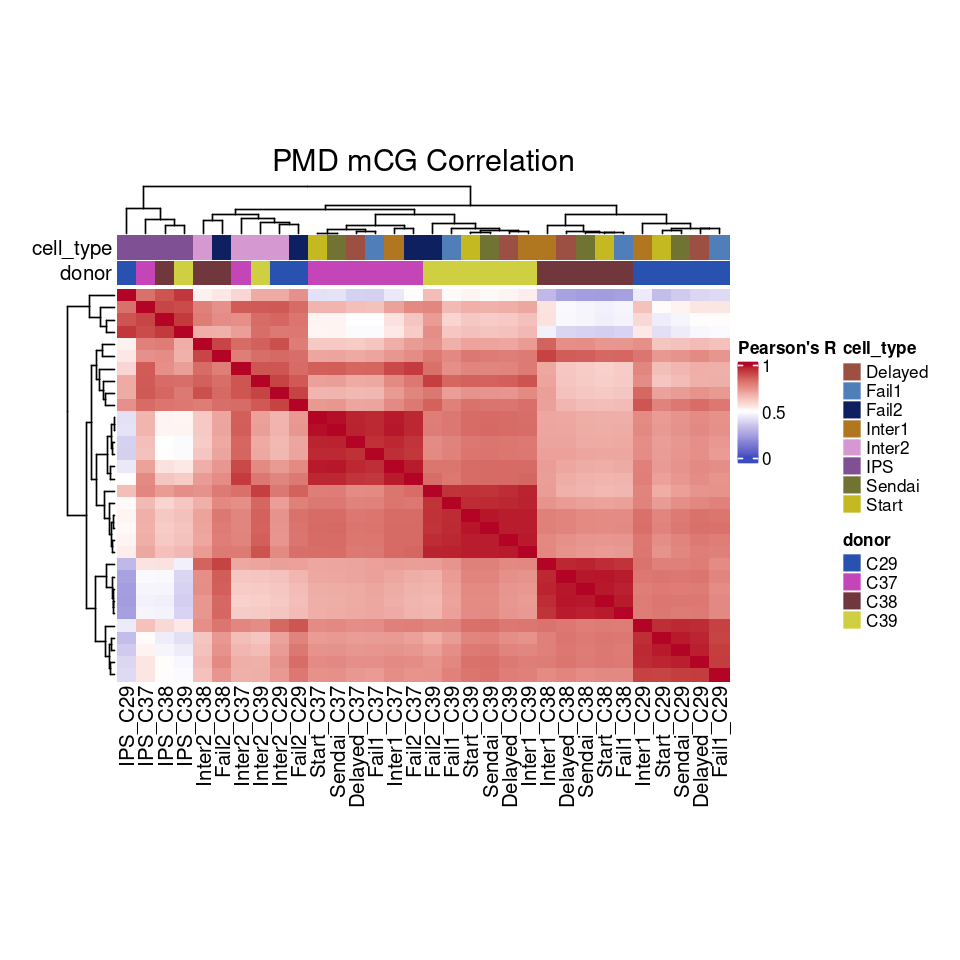

In [ ]:
linkage_path = paste0(projdir, '/csv/figure2/rna_cluster_donor_linkage.csv')
  lnk <- as.matrix(fread(linkage_path))

linkage_labels_path = paste0(projdir, '/csv/figure2/rna_cluster_donor_linkage_labels.csv')
lnk_labels <- fread(linkage_labels_path, header = FALSE)[[1]]

n <- length(lnk_labels)
merge_mat <- matrix(0L, nrow(lnk), 2)
for (i in seq_len(nrow(lnk))) {
l <- lnk[i, 1]; r <- lnk[i, 2]
merge_mat[i, 1] <- if (l < n) -(l + 1L) else as.integer(l - n + 1)
merge_mat[i, 2] <- if (r < n) -(r + 1L) else as.integer(r - n + 1)
}
hc <- structure(
list(merge = merge_mat, height = lnk[, 3],
     order = seq_len(n), labels = lnk_labels, method = "average"),
class = "hclust"
)
hc$order <- order.dendrogram(as.dendrogram(hc))
row_dend  <- as.dendrogram(hc)
col_dend  <- row_dend

pmd_matrix_path = paste0(projdir, '/csv/figure2/rna_cluster_donor_pmd_mcg.csv')
pmd_matrix = as.data.frame(fread(pmd_matrix_path, sep='\t'))
rownames(pmd_matrix) <- pmd_matrix$V1
pmd_matrix <- pmd_matrix[,-1]

ct_split <- sapply(strsplit(colnames(pmd_matrix), '_'), `[`, 1)
donor_split <- sapply(strsplit(colnames(pmd_matrix), '_'), `[`, 2)

col_fun <- colorRamp2(c(0, 0.5, 1.0), c("#3B4CC0", "white", "#B40426"))

top_ha <- HeatmapAnnotation(
  cell_type = ct_split,
  donor     = donor_split,
  col = list(
    cell_type = all_hexes,
    donor     = donor_hexes
  ),
  annotation_name_side = "left",
  annotation_name_gp   = gpar(fontsize = 12)
)

w = 8
h = 8
options(repr.plot.width = w, repr.plot.height = h)

p1 <- Heatmap(
      pmd_matrix,
      name = "Pearson's R",
      col = col_fun,
      row_names_side = "left",
      column_names_side = "bottom",
      show_row_names = FALSE,
      show_column_names = TRUE,
      cluster_rows = row_dend,
      cluster_columns = col_dend,
        heatmap_width = unit(14, "cm"),
        heatmap_height = unit(14, "cm"),
      row_names_gp = gpar(fontsize = 12),
      column_names_gp = gpar(fontsize = 12),
      column_title_gp = gpar(fontsize = 18),
      column_names_rot = 90,
      row_title_rot = 90,
      column_title = 'PMD mCG Correlation',
      top_annotation = top_ha
      )

p <- as.ggplot(p1) +
        base_theme
p

In [ ]:
sessionInfo()

In [ ]:
Sys.time()